In [12]:
import torch
from pathlib import Path
from IPython.display import Audio, display
from tts.vocoder import load_model, mel_to_audio_vocos

# load_model()

RUN_DIR = Path("./runs/run_gaussian_003")

def play_eval_spec(epoch, sample_idx=0):
    path = RUN_DIR / "specs" / f"epoch_{epoch:03d}_{sample_idx:02d}.pt"
    data = torch.load(path, weights_only=True)
    spec = data["spec"].float()   # (n_mels, T)
    text = data["text"]

    # vocos expects (1, n_mels, T)
    audio = mel_to_audio_vocos(spec.unsqueeze(0))

    print(f"epoch {epoch}  |  \"{text}\"")
    display(Audio(audio, rate=24000))

def return_mel(epoch, sample_idx=0):
    path = RUN_DIR / "specs" / f"epoch_{epoch:03d}_{sample_idx:02d}.pt"
    data = torch.load(path, weights_only=True)
    spec = data["spec"].float()   # (n_mels, T)
    text = data["text"]
    print(text)

    # vocos expects (1, n_mels, T)
    return spec.unsqueeze(0)


The quick brown fox jumps over the lazy dog.


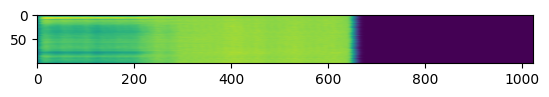

In [30]:
mel = return_mel(epoch=1, sample_idx=1).numpy()[0,:,:]
import matplotlib.pyplot as plt
plt.imshow(mel)

Let's try a really long string to see what happens. And maybe a second sentence too?


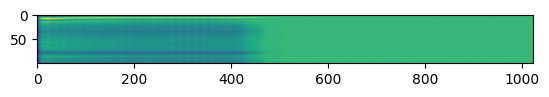

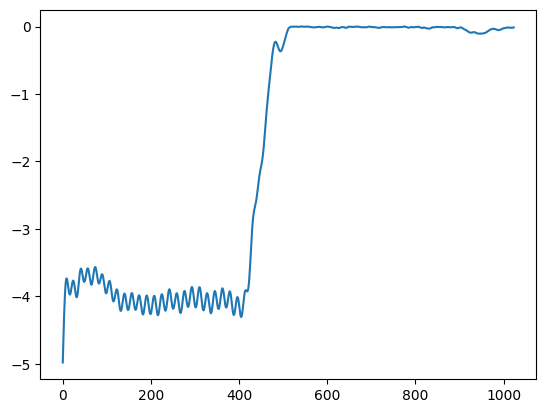

In [39]:
mel = return_mel(epoch=6, sample_idx=5).numpy()[0,:,:]
import matplotlib.pyplot as plt
plt.imshow(mel)
plt.figure()
plt.plot(mel.min(axis=0))

In [ ]:
Hey so I see weird results. I ran for 6 epochs so far. I see:

like 200 frames of frequency structure (very smoothed), followed by like 400 frames of pretty much exactly 0, then a sharp drop to the rest at -8 ish

Why is this happening? I would not expect this flat line at 0. I would expect what I see in the first 200 frames instead to go all the way across.

It imples the first tokens are learning some structure, but the later tokens are all at a flat value of 0. Is there a bug in the code somewhere?







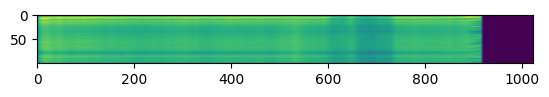

In [34]:
import matplotlib.pyplot as plt
plt.imshow(mel)

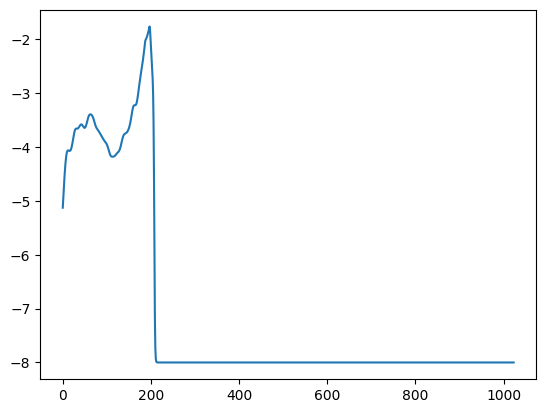

In [28]:
plt.plot(mel.min(axis=0))

In [83]:
-7e-7

'/Users/dominicbates/Documents/Github/SimpleTTS/notebooks/throwaway'

In [84]:
import torch

sample = torch.load("/Users/dominicbates/Documents/Github/SimpleTTS/data/jenny/samples/000005.pt", weights_only=True)

mel  = sample["mel"].float()   # (1, 100, T)
text = sample["text"]

print(f"text:  {text}")
print(f"shape: {mel.shape}")
print(f"min:   {mel.min().item():.2f}")
print(f"max:   {mel.max().item():.2f}")
print(f"mean:  {mel.mean().item():.2f}")
print(f"duration: {mel.shape[-1] / 93.75:.2f}s  ({mel.shape[-2]} frames)")

text:  The next day was fine, and Meg departed in style for a fortnight of novelty and pleasure.
shape: torch.Size([1, 100, 564])
min:   -8.15
max:   3.90
mean:  -1.51
duration: 6.02s  (100 frames)


In [85]:
mel.shape

torch.Size([1, 100, 564])

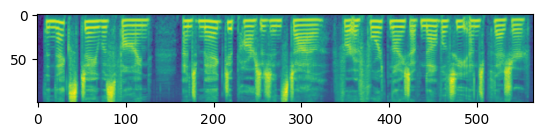

In [86]:
import matplotlib.pyplot as plt
plt.imshow(mel[0,:,:])

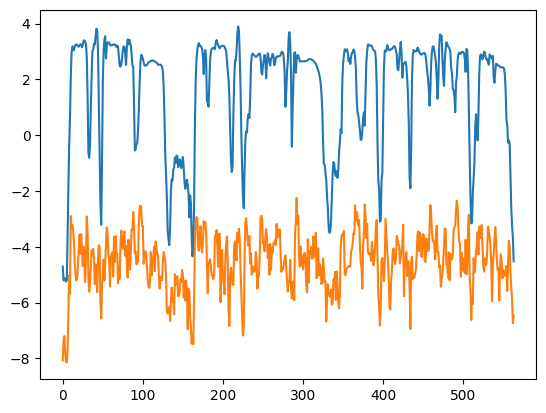

In [77]:
# plt.plot(mel[0,:,:].percentile(axis=0))
import numpy as np
plt.plot(np.max(mel[0,:,:].numpy(), axis=0))
plt.plot(np.min(mel[0,:,:].numpy(), axis=0))

In [ ]:
min values along the mel axis are like -8 and max values are like 4